# Model Interpretation & Governance

This notebook loads the trained models and evaluation artifacts from `../artifacts/` and focuses on:

1. Interpreting model behavior (Logistic Regression coefficients, tree feature importance)  
2. Linking results to credit-risk intuition (drivers of default risk)  
3. Governance considerations (threshold policy, monitoring, drift)

In [38]:
# --- Standard library ---
import os
import sys
import joblib

# Add project root to path so we can import config.py
sys.path.append("..")

# --- Core libs ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- sklearn ---
from sklearn.model_selection import train_test_split

# (Optional) for nicer notebook display headings
from IPython.display import display, Markdown

# --- SHAP (tree explanations) ---
import shap

# --- Project configuration (shared across notebooks) ---
from config import (
    COLUMN_RENAME_MAP,
    NUMERICAL_FEATURES,
    ORDINAL_FEATURES,
    CATEGORICAL_FEATURES,
    BINARY_FEATURES
)

# --- Paths ---
DATA_PATH = "../data/raw/german_credit_data.csv"
ARTIFACT_DIR = "../artifacts"

# Display settings (optional)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# ======================================================
# Load saved models + metric tables
# ======================================================

lr  = joblib.load(os.path.join(ARTIFACT_DIR, "Logistic_Regression.joblib"))
rf  = joblib.load(os.path.join(ARTIFACT_DIR, "Random_Forest.joblib"))
xgb = joblib.load(os.path.join(ARTIFACT_DIR, "XGBoost.joblib"))

models_loaded = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

baseline_df  = pd.read_csv(os.path.join(ARTIFACT_DIR, "baseline_metrics.csv"))
threshold_df = pd.read_csv(os.path.join(ARTIFACT_DIR, "threshold_results.csv"))
cost_opt_df  = pd.read_csv(os.path.join(ARTIFACT_DIR, "cost_opt_results.csv"))
calib_df     = pd.read_csv(os.path.join(ARTIFACT_DIR, "calibration_metrics.csv"))

# ======================================================
# Recreate dataset + exact test split (for SHAP/plots)
# MUST match training notebook settings
# ======================================================

df = pd.read_csv(DATA_PATH)
df = df.rename(columns=COLUMN_RENAME_MAP)

df["default"] = 1 - df["kredit"]
df = df.drop(columns=["kredit"])

X = df.drop(columns=["default"])
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Loaded artifacts + recreated train/test split.")
print("Test set size:", X_test.shape)


Loaded artifacts + recreated train/test split.
Test set size: (250, 20)


## Recap of Evaluation Results

We summarize three perspectives:

- **Ranking (ROC-AUC / PR-AUC)**: threshold-independent discrimination  
- **Recall-constrained thresholding**: policy view (e.g., minimum detection requirement)  
- **Cost-optimal thresholding**: economic view (minimize weighted FP/FN costs)  
- **Calibration**: reliability of predicted PDs


In [39]:
print("=== Baseline ranking metrics ===")
print(baseline_df.to_string(index=False))

print("\n=== Cost-optimal thresholds (saved) ===")
print(cost_opt_df.to_string(index=False))


=== Baseline ranking metrics ===
              Model  ROC-AUC   PR-AUC
      Random Forest 0.777219 0.657006
            XGBoost 0.775314 0.644512
Logistic Regression 0.755810 0.602837

=== Cost-optimal thresholds (saved) ===
              Model FN:FP ratio  Threshold  Cost   Recall  Precision       F1  Pred_Default_Rate  TP  FP  FN  TN
Logistic Regression         5:1     0.0885 132.0 0.973333   0.374359 0.540741              0.780  73 122   2  53
Logistic Regression        10:1     0.0885 142.0 0.973333   0.374359 0.540741              0.780  73 122   2  53
      Random Forest         5:1     0.2035 133.0 0.920000   0.401163 0.558704              0.688  69 103   6  72
      Random Forest        10:1     0.1500 152.0 0.960000   0.371134 0.535316              0.776  72 122   3  53
            XGBoost         5:1     0.0720 139.0 0.893333   0.403614 0.556017              0.664  67  99   8  76
            XGBoost        10:1     0.0255 150.0 0.973333   0.359606 0.525180              0.812

## Interpretation Part A: Logistic Regression Coefficients

In [40]:
lr_feature_names = lr.named_steps["preprocess"].get_feature_names_out()
lr_coefs = lr.named_steps["model"].coef_[0]

lr_coef_df = pd.DataFrame({
    "Feature": lr_feature_names,
    "Coefficient": lr_coefs,
    "Odds_Ratio": np.exp(lr_coefs)
})

# Make feature names easier to read
def clean_feat_name(s: str) -> str:
    return s.split("__", 1)[1] if "__" in s else s

lr_coef_df["Feature"] = lr_coef_df["Feature"].map(clean_feat_name)

# Show strongest positive + negative effects (more interpretable than absolute-only)
top_pos = lr_coef_df.sort_values("Coefficient", ascending=False).head(10)
top_neg = lr_coef_df.sort_values("Coefficient", ascending=True).head(10)

print("\n=== Logistic Regression: strongest risk-increasing features (top +) ===")
print(top_pos.to_string(index=False))

print("\n=== Logistic Regression: strongest risk-decreasing features (top -) ===")
print(top_neg.to_string(index=False))



=== Logistic Regression: strongest risk-increasing features (top +) ===
         Feature  Coefficient  Odds_Ratio
  foreign_worker     1.012809    2.753324
      property_4     0.617330    1.853972
credit_history_1     0.439958    1.552642
          amount     0.409059    1.505401
      property_2     0.301274    1.351580
  number_credits     0.295526    1.343834
installment_rate     0.286883    1.332268
        duration     0.267397    1.306558
 other_debtors_2     0.198893    1.220051
             job     0.152302    1.164512

=== Logistic Regression: strongest risk-decreasing features (top -) ===
              Feature  Coefficient  Odds_Ratio
            purpose_1    -1.631228    0.195689
     credit_history_4    -1.304181    0.271395
            savings_4    -1.020349    0.360469
            savings_5    -0.964160    0.381303
            purpose_3    -0.745329    0.474578
     credit_history_3    -0.729844    0.481984
           purpose_10    -0.712711    0.490313
      other_debt

## Interpretation Part B: Tree Model Feature Importance

In [41]:
rf_feature_names = rf.named_steps["preprocess"].get_feature_names_out()
xgb_feature_names = xgb.named_steps["preprocess"].get_feature_names_out()

rf_importances = rf.named_steps["model"].feature_importances_
xgb_importances = xgb.named_steps["model"].feature_importances_

rf_imp_df = pd.DataFrame({
    "Feature": [clean_feat_name(f) for f in rf_feature_names],
    "Importance": rf_importances
}).sort_values("Importance", ascending=False)

xgb_imp_df = pd.DataFrame({
    "Feature": [clean_feat_name(f) for f in xgb_feature_names],
    "Importance": xgb_importances
}).sort_values("Importance", ascending=False)

print("\n=== Random Forest: Top 15 importances ===")
print(rf_imp_df.head(15).to_string(index=False))

print("\n=== XGBoost: Top 15 importances ===")
print(xgb_imp_df.head(15).to_string(index=False))



=== Random Forest: Top 15 importances ===
              Feature  Importance
               amount    0.114186
               status    0.099406
                  age    0.083892
             duration    0.081982
  employment_duration    0.045465
     installment_rate    0.038218
    present_residence    0.036196
                  job    0.029084
     credit_history_4    0.025490
            savings_1    0.024160
            purpose_0    0.020815
       number_credits    0.018748
            telephone    0.017669
           property_1    0.017367
personal_status_sex_2    0.017233

=== XGBoost: Top 15 importances ===
                  Feature  Importance
                   status    0.076127
         credit_history_4    0.043532
               property_1    0.034500
                purpose_1    0.032217
                savings_1    0.032178
                purpose_0    0.030109
               property_4    0.029366
                savings_5    0.029198
                 duration    0.027

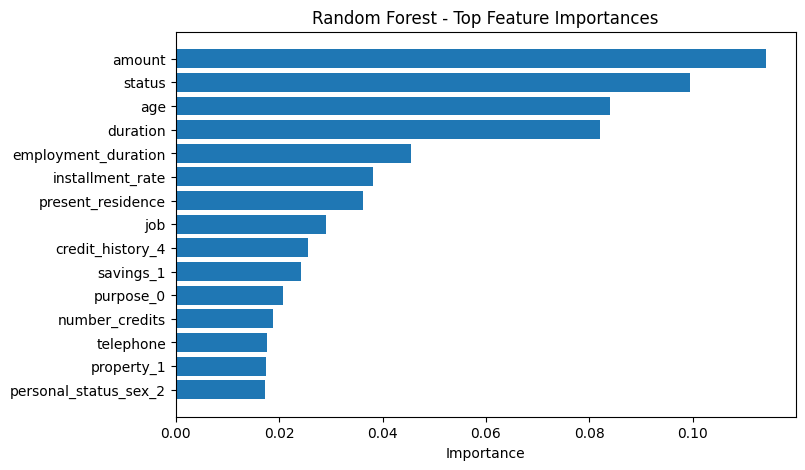

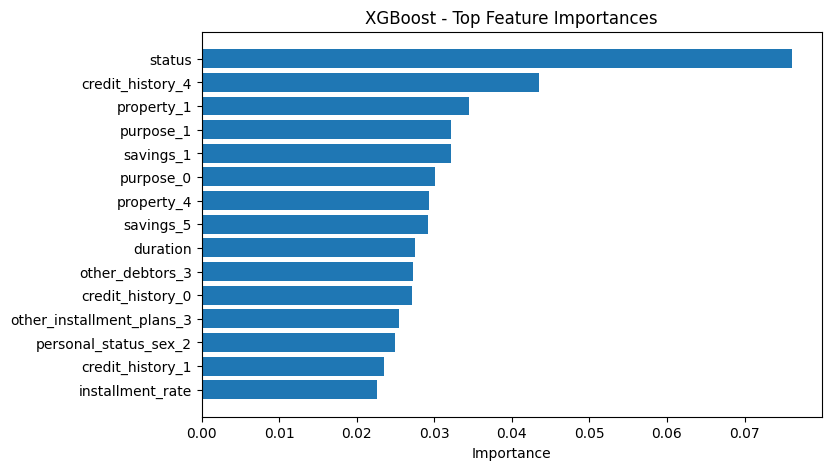

In [42]:
def plot_top_importances(df, title, top_n=15):
    top = df.head(top_n).iloc[::-1]
    plt.figure(figsize=(8, 5))
    plt.barh(top["Feature"], top["Importance"])
    plt.title(title)
    plt.xlabel("Importance")
    plt.show()

plot_top_importances(rf_imp_df, "Random Forest - Top Feature Importances", top_n=15)
plot_top_importances(xgb_imp_df, "XGBoost - Top Feature Importances", top_n=15)


## Interpretation Part C: Compare drivers across models

In [43]:
def base_feature(feat: str) -> str:
    # examples:
    # "cat__purpose_A40" -> "purpose"
    # "num__amount" -> "amount"
    # "ord__status" -> "status"
    # After clean_feat_name: "purpose_A40" -> "purpose"
    feat = clean_feat_name(feat)
    return feat.split("_", 1)[0] if "_" in feat else feat

# LR: aggregate absolute coefficients by base feature
lr_base = lr_coef_df.copy()
lr_base["Base_Feature"] = lr_base["Feature"].apply(base_feature)
lr_base["Abs_Coefficient"] = lr_base["Coefficient"].abs()
lr_base_agg = (lr_base.groupby("Base_Feature", as_index=False)["Abs_Coefficient"]
               .sum()
               .sort_values("Abs_Coefficient", ascending=False)
               .rename(columns={"Abs_Coefficient": "LR_abs_coef_sum"}))

# RF/XGB: aggregate importances by base feature
rf_base = rf_imp_df.copy()
rf_base["Base_Feature"] = rf_base["Feature"].apply(base_feature)
rf_base_agg = (rf_base.groupby("Base_Feature", as_index=False)["Importance"]
               .sum()
               .sort_values("Importance", ascending=False)
               .rename(columns={"Importance": "RF_importance_sum"}))

xgb_base = xgb_imp_df.copy()
xgb_base["Base_Feature"] = xgb_base["Feature"].apply(base_feature)
xgb_base_agg = (xgb_base.groupby("Base_Feature", as_index=False)["Importance"]
                .sum()
                .sort_values("Importance", ascending=False)
                .rename(columns={"Importance": "XGB_importance_sum"}))

# Merge into one overview table
overview = (lr_base_agg.merge(rf_base_agg, on="Base_Feature", how="outer")
                    .merge(xgb_base_agg, on="Base_Feature", how="outer")
                    .fillna(0))

# Optional: normalize columns to sum to 1 for comparability
overview["LR_norm"] = overview["LR_abs_coef_sum"] / overview["LR_abs_coef_sum"].sum()
overview["RF_norm"] = overview["RF_importance_sum"] / overview["RF_importance_sum"].sum()
overview["XGB_norm"] = overview["XGB_importance_sum"] / overview["XGB_importance_sum"].sum()

overview = overview.sort_values("XGB_norm", ascending=False)

print("\n=== Driver comparison (aggregated to base feature; normalized) ===")
print(overview[["Base_Feature", "LR_norm", "RF_norm", "XGB_norm"]].head(15).to_string(index=False))



=== Driver comparison (aggregated to base feature; normalized) ===
Base_Feature  LR_norm  RF_norm  XGB_norm
     purpose 0.285370 0.091339  0.145800
      credit 0.151362 0.072636  0.126761
       other 0.069257 0.059256  0.114025
     savings 0.140941 0.058648  0.112986
    property 0.053617 0.057385  0.093197
      status 0.030552 0.099406  0.076127
    personal 0.058020 0.049357  0.075166
     housing 0.039642 0.030668  0.043016
    duration 0.014637 0.081982  0.027475
 installment 0.015704 0.038218  0.022648
  employment 0.005566 0.045465  0.021085
         job 0.008337 0.029084  0.018799
      amount 0.022392 0.114186  0.018559
      people 0.009366 0.011903  0.018379
     present 0.001870 0.036196  0.018151


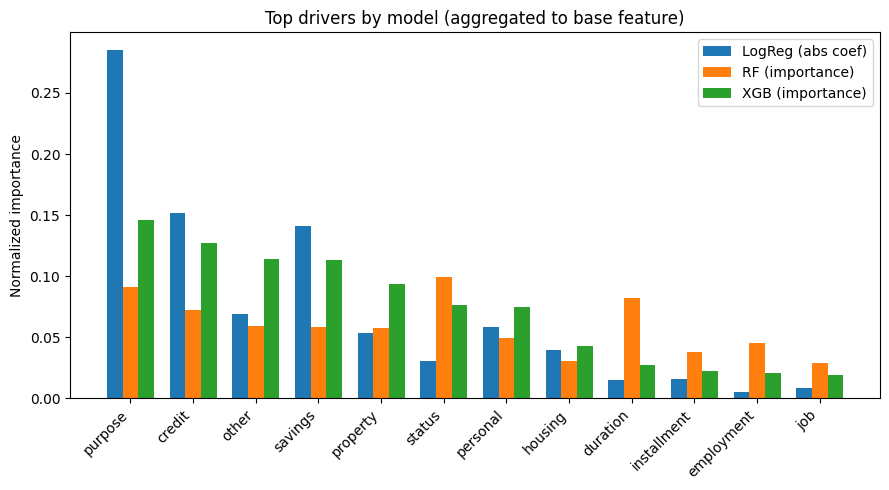

In [44]:
top_k = 12
plot_df = overview.sort_values("XGB_norm", ascending=False).head(top_k)

plt.figure(figsize=(9, 5))
x = np.arange(len(plot_df))
w = 0.25
plt.bar(x - w, plot_df["LR_norm"], width=w, label="LogReg (abs coef)")
plt.bar(x,      plot_df["RF_norm"], width=w, label="RF (importance)")
plt.bar(x + w,  plot_df["XGB_norm"], width=w, label="XGB (importance)")
plt.xticks(x, plot_df["Base_Feature"], rotation=45, ha="right")
plt.ylabel("Normalized importance")
plt.title("Top drivers by model (aggregated to base feature)")
plt.legend()
plt.tight_layout()
plt.show()


## SHAP Anaylsis (Tree Models)


In [45]:
def get_transformed_X_and_names(pipeline, X):
    pre = pipeline.named_steps["preprocess"]
    X_trans = pre.transform(X)
    feature_names = pre.get_feature_names_out()
    return X_trans, feature_names

N_SHAP = 500

idx = X_test.sample(n=min(N_SHAP, len(X_test)), random_state=42).index
X_shap = X_test.loc[idx]
y_shap = y_test.loc[idx]  # optional but useful later

X_rf_trans, rf_feat_names = get_transformed_X_and_names(rf, X_shap)
X_xgb_trans, xgb_feat_names = get_transformed_X_and_names(xgb, X_shap)


### Compute SHAP Values

In [46]:
# --- Random Forest ---
rf_model = rf.named_steps["model"]
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap = rf_explainer.shap_values(X_rf_trans)

# Handle different RF output formats
if isinstance(rf_shap, list):
    # old SHAP versions: list of arrays per class
    rf_shap = rf_shap[1]
elif isinstance(rf_shap, np.ndarray) and rf_shap.ndim == 3:
    # newer versions: (samples, features, classes)
    rf_shap = rf_shap[:, :, 1]

# --- XGBoost ---
xgb_model = xgb.named_steps["model"]
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap = xgb_explainer.shap_values(X_xgb_trans)

# Handle possible list output
if isinstance(xgb_shap, list):
    xgb_shap = xgb_shap[1]

print("RF SHAP shape:", np.array(rf_shap).shape)
print("XGB SHAP shape:", np.array(xgb_shap).shape)
print("RF features:", len(rf_feat_names))
print("XGB features:", len(xgb_feat_names))


RF SHAP shape: (250, 49)
XGB SHAP shape: (250, 49)
RF features: 49
XGB features: 49


In [47]:
def clean_feat_names(feature_names):
    return [f.split("__", 1)[1] if "__" in f else f for f in feature_names]

rf_feat_clean = clean_feat_names(rf_feat_names)
xgb_feat_clean = clean_feat_names(xgb_feat_names)


### Plot SHAP Values

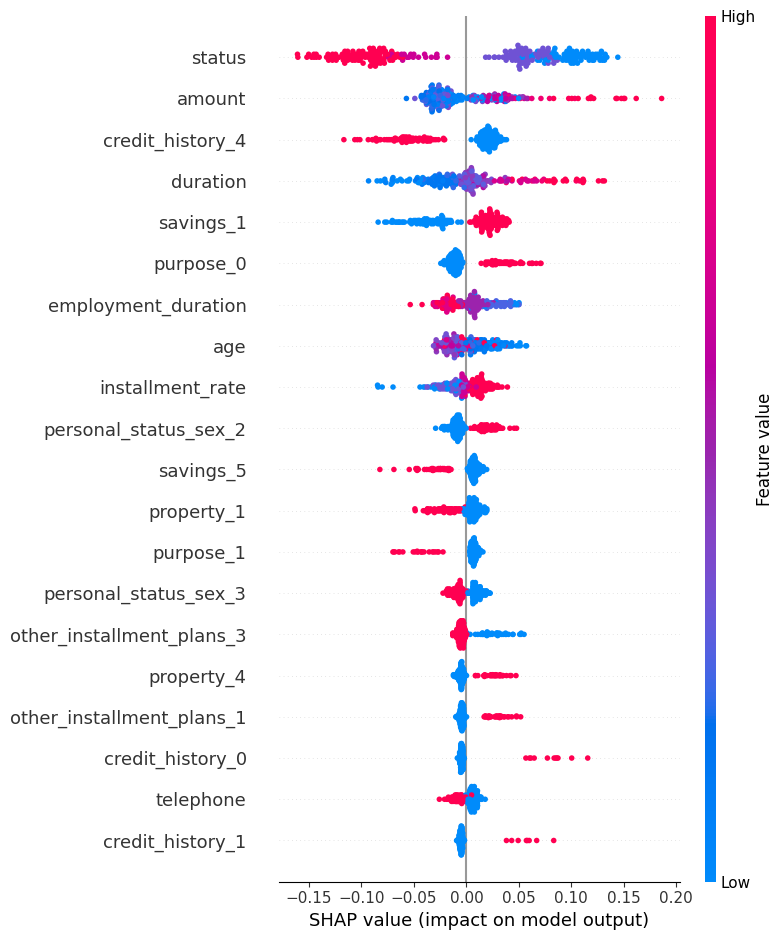

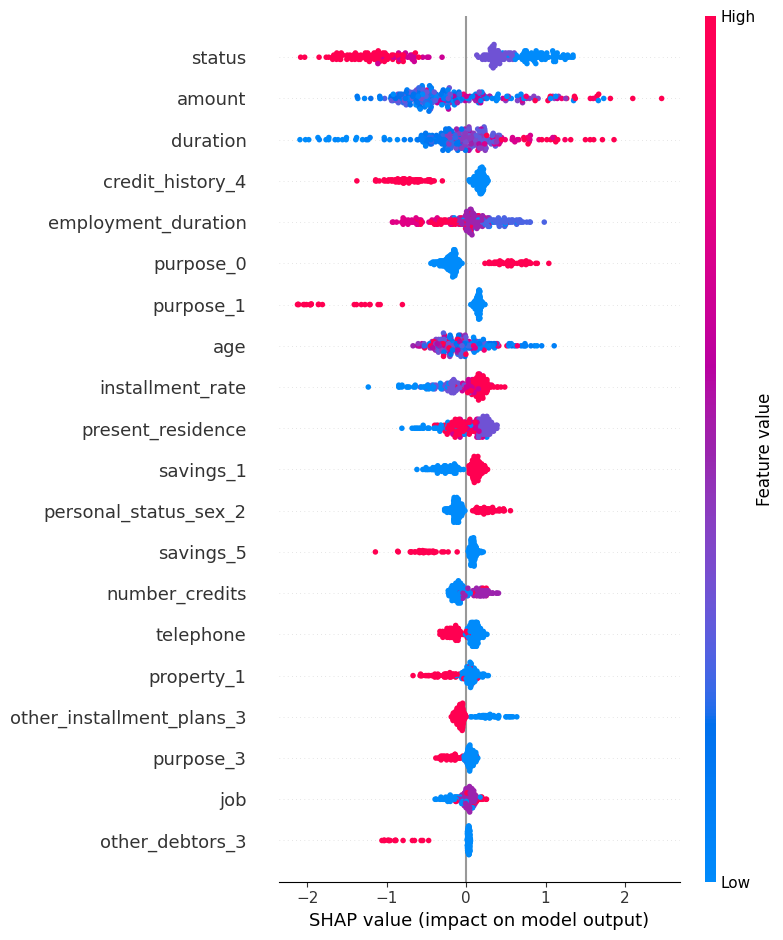

In [48]:
shap.summary_plot(rf_shap, X_rf_trans, feature_names=rf_feat_clean, show=True)
shap.summary_plot(xgb_shap, X_xgb_trans, feature_names=xgb_feat_clean, show=True)


## Governance

### Portfolio bias monitoring (mean PD vs observed default rate)

In [49]:
def portfolio_bias_table(models_dict, X, y):
    rows = []
    default_rate = float(y.mean())
    for name, model in models_dict.items():
        pd_hat = model.predict_proba(X)[:, 1]
        mean_pd = float(pd_hat.mean())
        rows.append({
            "Model": name,
            "Mean predicted PD": mean_pd,
            "Observed default rate": default_rate,
            "Bias (meanPD - defaultRate)": mean_pd - default_rate
        })
    return pd.DataFrame(rows).sort_values("Bias (meanPD - defaultRate)")

bias_df = portfolio_bias_table(models_loaded, X_test, y_test)
print("\n=== Portfolio Bias Monitoring (test set) ===")
print(bias_df.to_string(index=False))



=== Portfolio Bias Monitoring (test set) ===
              Model  Mean predicted PD  Observed default rate  Bias (meanPD - defaultRate)
            XGBoost           0.288248                    0.3                    -0.011752
Logistic Regression           0.304768                    0.3                     0.004768
      Random Forest           0.306184                    0.3                     0.006184



### Portfolio Bias Monitoring

### Results (Test Set)

| Model | Mean PD | Observed Default | Bias |
|--------|---------|-----------------|-------|
| XGBoost | 0.288 | 0.30 | -0.0118 |
| Logistic Regression | 0.305 | 0.30 | +0.0048 |
| Random Forest | 0.306 | 0.30 | +0.0062 |

### Interpretation

- All biases are small (≈ ±1%)
- No systematic portfolio-level underpricing
- No immediate solvency red flag

### Story Implication

The models are **not introducing aggregate pricing risk**.

This supports the earlier calibration findings and indicates
that ML is not creating hidden portfolio-level bias.

**Governance relevance:**
- Basel IRB PD backtesting requirements
- ECB TRIM calibration checks
- SR 11-7 Model Risk Management (ongoing performance review)

Good governance signal.


### PSI drift monitoring (train vs. test) - PD distribution + features

In [50]:
def psi(expected, actual, bins=10):
    expected = np.asarray(expected)
    actual = np.asarray(actual)

    # same bin edges for both
    edges = np.quantile(np.concatenate([expected, actual]), np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf  # catch all

    exp_counts, _ = np.histogram(expected, bins=edges)
    act_counts, _ = np.histogram(actual, bins=edges)

    exp_perc = exp_counts / max(exp_counts.sum(), 1)
    act_perc = act_counts / max(act_counts.sum(), 1)

    # avoid division by zero
    eps = 1e-6
    exp_perc = np.clip(exp_perc, eps, None)
    act_perc = np.clip(act_perc, eps, None)

    return float(np.sum((act_perc - exp_perc) * np.log(act_perc / exp_perc)))

# --- 2a) PSI on predicted PD distribution ---
psi_rows = []
for name, model in models_loaded.items():
    pd_train = model.predict_proba(X_train)[:, 1]
    pd_test  = model.predict_proba(X_test)[:, 1]
    psi_rows.append({"Model": name, "PSI_PD (train vs test)": psi(pd_train, pd_test, bins=10)})

psi_pd_df = pd.DataFrame(psi_rows).sort_values("PSI_PD (train vs test)")
print("\n=== PSI Drift: Predicted PD distribution ===")
print(psi_pd_df.to_string(index=False))

# --- 2b) PSI on key raw features (train vs test) ---
key_features = ["duration", "amount", "age", "status", "employment_duration"]

feat_rows = []
for feat in key_features:
    feat_rows.append({"Feature": feat, "PSI_feature (train vs test)": psi(X_train[feat], X_test[feat], bins=10)})

psi_feat_df = pd.DataFrame(feat_rows).sort_values("PSI_feature (train vs test)", ascending=False)
print("\n=== PSI Drift: Key feature distributions (raw) ===")
print(psi_feat_df.to_string(index=False))



=== PSI Drift: Predicted PD distribution ===
              Model  PSI_PD (train vs test)
Logistic Regression                0.015408
            XGBoost                0.394868
      Random Forest                3.712431

=== PSI Drift: Key feature distributions (raw) ===
            Feature  PSI_feature (train vs test)
             amount                     0.044085
employment_duration                     0.038372
                age                     0.021581
           duration                     0.015098
             status                     0.006779


### PSI — Predicted PD Drift

### Results (Train vs Test)

| Model | PSI (PD train vs test) |
|--------|------------------------|
| Logistic Regression | 0.015 |
| XGBoost | 0.395 |
| Random Forest | 3.71 |

### PSI Interpretation Thresholds

- PSI < 0.1 → No drift
- 0.1–0.25 → Moderate drift
- > 0.25 → Significant drift

### Interpretation

- Logistic Regression: Stable
- XGBoost: Significant drift
- Random Forest: Extreme instability

Although feature distributions are stable,
tree models show **model-driven PD instability**.

This highlights structural sensitivity of tree ensembles.

**Governance relevance:**
- SR 11-7 ongoing monitoring
- EBA model validation principles (stability checks)
- Change management requirements


### PSI — Raw Feature Drift

### Feature PSI Values

- amount: 0.044
- employment_duration: 0.038
- age: 0.022
- duration: 0.015
- status: 0.007

All values are very low.

### Interpretation

There is **no meaningful feature drift** between train and test.

Therefore:

> PD instability is model-driven, not data-driven.

### Story Implication

Instability arises from model structure,
not portfolio composition changes.

This strengthens the governance argument:
Tree models require stronger monitoring controls.

Good analytical insight.



### SHAP stability monitoring (train vs test)

In [51]:
def mean_abs_shap(shap_vals):
    return np.mean(np.abs(shap_vals), axis=0)

def shap_top_table(shap_vals, feat_names, top_n=15):
    df_ = pd.DataFrame({
        "Feature": feat_names,
        "MeanAbsSHAP": mean_abs_shap(shap_vals)
    }).sort_values("MeanAbsSHAP", ascending=False)
    return df_.head(top_n)

N_SHAP = 500
idx_tr = X_train.sample(n=min(N_SHAP, len(X_train)), random_state=42).index
idx_te = X_test.sample(n=min(N_SHAP, len(X_test)), random_state=42).index

X_shap_tr = X_train.loc[idx_tr]
X_shap_te = X_test.loc[idx_te]

# transform
X_rf_tr, rf_names = get_transformed_X_and_names(rf, X_shap_tr)
X_rf_te, _        = get_transformed_X_and_names(rf, X_shap_te)

X_xgb_tr, xgb_names = get_transformed_X_and_names(xgb, X_shap_tr)
X_xgb_te, _         = get_transformed_X_and_names(xgb, X_shap_te)

rf_names_clean  = clean_feat_names(rf_names)
xgb_names_clean = clean_feat_names(xgb_names)

# explainers
rf_expl = shap.TreeExplainer(rf.named_steps["model"])
xgb_expl = shap.TreeExplainer(xgb.named_steps["model"])

# SHAP values
rf_shap_tr = rf_expl.shap_values(X_rf_tr)
rf_shap_te = rf_expl.shap_values(X_rf_te)
if isinstance(rf_shap_tr, list): rf_shap_tr = rf_shap_tr[1]
if isinstance(rf_shap_te, list): rf_shap_te = rf_shap_te[1]
if isinstance(rf_shap_tr, np.ndarray) and rf_shap_tr.ndim == 3: rf_shap_tr = rf_shap_tr[:, :, 1]
if isinstance(rf_shap_te, np.ndarray) and rf_shap_te.ndim == 3: rf_shap_te = rf_shap_te[:, :, 1]

xgb_shap_tr = xgb_expl.shap_values(X_xgb_tr)
xgb_shap_te = xgb_expl.shap_values(X_xgb_te)
if isinstance(xgb_shap_tr, list): xgb_shap_tr = xgb_shap_tr[1]
if isinstance(xgb_shap_te, list): xgb_shap_te = xgb_shap_te[1]

print("\n=== SHAP Stability (RF): Top drivers train vs test ===")
display(shap_top_table(rf_shap_tr, rf_names_clean, top_n=15))
display(shap_top_table(rf_shap_te, rf_names_clean, top_n=15))

print("\n=== SHAP Stability (XGB): Top drivers train vs test ===")
display(shap_top_table(xgb_shap_tr, xgb_names_clean, top_n=15))
display(shap_top_table(xgb_shap_te, xgb_names_clean, top_n=15))



=== SHAP Stability (RF): Top drivers train vs test ===


,Feature,MeanAbsSHAP
40,status,0.086116
1,amount,0.035461
0,duration,0.032388
7,credit_history_4,0.030736
18,savings_1,0.027553
2,age,0.021017
41,employment_duration,0.019244
8,purpose_0,0.016660
42,installment_rate,0.014928
24,personal_status_sex_2,0.012893


,Feature,MeanAbsSHAP
40,status,0.085952
1,amount,0.033164
7,credit_history_4,0.032975
0,duration,0.029011
18,savings_1,0.027956
8,purpose_0,0.017507
41,employment_duration,0.017350
2,age,0.016562
42,installment_rate,0.014276
24,personal_status_sex_2,0.013168



=== SHAP Stability (XGB): Top drivers train vs test ===


,Feature,MeanAbsSHAP
40,status,0.908065
1,amount,0.597556
0,duration,0.470600
7,credit_history_4,0.340487
9,purpose_1,0.328684
41,employment_duration,0.315770
2,age,0.281062
8,purpose_0,0.269893
42,installment_rate,0.215909
43,present_residence,0.194567


,Feature,MeanAbsSHAP
40,status,0.885836
1,amount,0.580392
0,duration,0.436723
7,credit_history_4,0.363883
41,employment_duration,0.294250
8,purpose_0,0.287932
9,purpose_1,0.284780
2,age,0.252192
42,installment_rate,0.215805
43,present_residence,0.198959


### SHAP Stability Check

### Random Forest

Top drivers (train vs test) are nearly identical.

### XGBoost

Feature ranking remains largely stable.

### Interpretation

- Drivers remain consistent
- No evidence of concept drift
- No structural change in model logic

Model reasoning appears stable.

### Governance Implication

- Reduces interpretability risk
- Supports ECB TRIM transparency expectations
- Aligns with AI Act explainability requirements
- Strengthens model validation documentation

Good governance signal.


### Threshold governance (make the threshold explicit + save policy table)

In [54]:
import os

# 1) Define policy target as a NUMBER (recommended)
policy_target = 0.80   # 80% recall

# 2) Create a numeric recall column regardless of how it's stored
#    Handles: 0.8, 80, "80%", "0.80", etc.
tr = threshold_df["Target recall"].copy()

if pd.api.types.is_numeric_dtype(tr):
    tr_num = tr.astype(float)
    # if someone stored 80 instead of 0.8
    if tr_num.max() > 1.0:
        tr_num = tr_num / 100.0
else:
    tr_str = tr.astype(str).str.strip()
    tr_str = tr_str.str.replace("%", "", regex=False)
    tr_num = pd.to_numeric(tr_str, errors="coerce")
    # if parsed as 80 instead of 0.8
    if tr_num.max() > 1.0:
        tr_num = tr_num / 100.0

threshold_df = threshold_df.copy()
threshold_df["TargetRecallNum"] = tr_num

# Optional: quick sanity check
print("Unique TargetRecallNum values (sorted):")
print(np.sort(threshold_df["TargetRecallNum"].dropna().unique()))

# 3) Filter with tolerance (avoids float equality issues)
tol = 1e-9
policy_tbl = (threshold_df[np.isclose(threshold_df["TargetRecallNum"], policy_target, atol=tol)]
              .copy()
              .sort_values(["Cost_10to1", "Cost_5to1", "F1"], ascending=[True, True, False]))

print(f"\n=== Threshold Policy Table (Target recall = {policy_target:.0%}) ===")
print(policy_tbl.to_string(index=False))

# 4) Save "approved" policy row (best by your sort rule)
if policy_tbl.empty:
    raise ValueError(
        f"No rows found for policy_target={policy_target}. "
        "Check the printed 'Unique TargetRecallNum values' above."
    )

approved = policy_tbl.iloc[[0]].copy()
approved["Policy"] = f"Recall target {policy_target:.0%} (example)"
approved_path = os.path.join(ARTIFACT_DIR, "threshold_policy_selected.csv")
approved.to_csv(approved_path, index=False)
print("\nSaved:", approved_path)


Unique TargetRecallNum values (sorted):
[0.65 0.7  0.75 0.8  0.85 0.9  0.95]

=== Threshold Policy Table (Target recall = 80%) ===
              Model  Target recall  Threshold  Recall  Precision       F1  TP  FP  FN  TN  Cost_5to1  Cost_10to1  TargetRecallNum
            XGBoost            0.8     0.1685     0.8   0.465116 0.588235  60  69  15 106      144.0       219.0              0.8
      Random Forest            0.8     0.2620     0.8   0.451128 0.576923  60  73  15 102      148.0       223.0              0.8
Logistic Regression            0.8     0.1925     0.8   0.422535 0.552995  60  82  15  93      157.0       232.0              0.8

Saved: ../artifacts\threshold_policy_selected.csv


### Governance Reflection: Is Threshold Policy Implementation Necessary?

At this stage, we already evaluated models across three layers:

1. **Ranking performance** (ROC-AUC, PR-AUC)  
2. **Decision-level risk** (recall constraints, cost-optimal thresholds)  
3. **Calibration & portfolio bias** (Brier, ECE, mean PD vs observed default)

From these analyses, we identified the key hidden risk:

> Model superiority depends entirely on the chosen objective (recall target, cost ratio, risk appetite).

This introduces **Governance Dependency Risk**:
- Different objectives → different “best” models  
- Without explicit policy definition → model selection becomes arbitrary  
- Arbitrary selection → capital planning and risk strategy instability  

---

### Do We Need Full Policy Implementation?

Technically:
- No additional heavy implementation is required.
- The analytical insight has already been demonstrated.

Conceptually:
- A governance layer is necessary to close the loop:
  - Hidden risk → Control mechanism

But governance here should remain **principle-based**, not procedural overkill.

---

### Lean Governance Conclusion

It is sufficient to state:

- Threshold policy must be explicitly defined.
- Risk appetite and cost assumptions must be documented.
- Model choice must align with institutional objectives.

This ensures:

- Stability in decision-making
- Avoidance of strategic drift
- Alignment with Model Risk Management (SR 11-7), Basel PD governance, and Three Lines of Defense principles

---

### Final Insight

The purpose of governance in this project is not operational theater.

It is to demonstrate that:

> ML models are not dangerous by themselves —  
> they become risky when objectives and controls are undefined.

This closes the story logically without unnecessary complexity.
